## What is an Outlier?
An outlier is a data point that differs significantly from other observations. They can result from variability in the data, measurement errors, or rare events.

## Standard Practices for Handling Outliers:

1. Visual Inspection:

- Boxplots, scatter plots, and histograms help visually identify outliers.

2. Statistical Methods:

- Z-score, IQR, or modified Z-score methods to detect outliers.

3. Domain Knowledge:

- Use known thresholds based on real-world knowledge.

4. Removal or Transformation:

- Remove or cap (clip) outliers.
- Apply transformations like log or Box-Cox.

5. Isolation-Based Methods:

- Use machine learning algorithms like Isolation Forest, DBSCAN, or One-Class SVM for high-dimensional data.

## Outlier removal using Z score

Z Score:
xi'=(xi-u)/std

#### Outlier Treatment
1. Trimming :- may cause loss of significant amount of data.
2. Capping :- 

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [3]:
df=pd.read_csv('dataset/placement.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


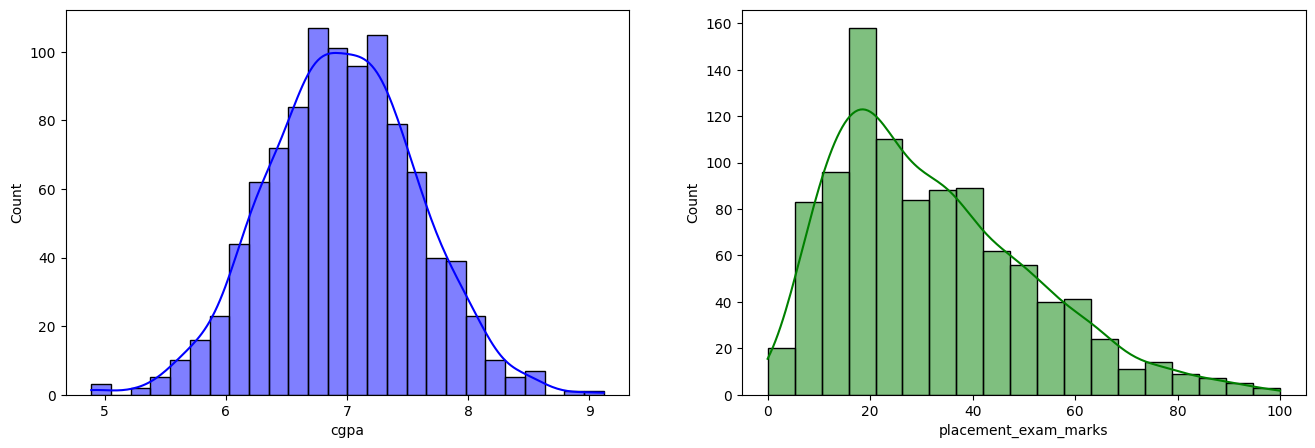

In [24]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(data=df,x='cgpa',fill=True,label='CGPA',color='blue',kde=True)

plt.subplot(1,2,2)
sns.histplot(data=df,x='placement_exam_marks',fill=True,label='Placement Exam Marks',color='green',kde=True)
plt.show()

In [26]:
print('Mean value of cgpa:',df['cgpa'].mean())
print('Std value of cgpa:',df['cgpa'].std())
print('Min value of cgpa:',df['cgpa'].min())
print('Max value of cgpa:',df['cgpa'].max())

Mean value of cgpa: 6.96124
Std value of cgpa: 0.6158978751323894
Min value of cgpa: 4.89
Max value of cgpa: 9.12


In [27]:
# finding the boundary values
print('Highest allowed',df['cgpa'].mean()+3*df['cgpa'].std())
print('Lowest allowed',df['cgpa'].mean()-3*df['cgpa'].std())

Highest allowed 8.808933625397168
Lowest allowed 5.113546374602832


In [29]:
# finding the outliers
df[(df['cgpa']>8.808) | (df['cgpa']<5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


#### Trimming

In [30]:
new_df=df[(df['cgpa']>8.808) | (df['cgpa']<5.11)]
new_df

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [31]:
## Calculating the Z-score for the 'cgpa' column

df['cgpa_zscore']=(df['cgpa']-df['cgpa'].mean())/df['cgpa'].std()
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [32]:
df[df['cgpa_zscore']>3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [34]:
df[df['cgpa_zscore']<-3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [36]:
df[(df['cgpa_zscore']<-3) | (df['cgpa_zscore']>3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [38]:
# Trimming the outliers
new_df=df[(df['cgpa_zscore']<3) & (df['cgpa_zscore']>-3)]
new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


In [39]:
## Upper and lower limit for the 'cgpa' column
upper_limit=df['cgpa'].mean()+3*df['cgpa'].std()
lower_limit=df['cgpa'].mean()-3*df['cgpa'].std()

In [40]:
print('upper_limit:',upper_limit)
print('lower_limit:',lower_limit)

upper_limit: 8.808933625397168
lower_limit: 5.113546374602832


In [41]:
df=np.where(
    df['cgpa_zscore']>3,upper_limit,
    np.where(df['cgpa_zscore']<-3,lower_limit,df['cgpa'])
)

In [44]:
df.shape

(1000,)